In [ ]:
import plotly.express as px
import pandas as pd

In [ ]:
data_set = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/loan_approval_data.csv')

In [ ]:
Transposed = data_set.describe().transpose()
Transposed

,count,mean,std,min,25%,50%,75%,max
id,58645.0,29322.000000,16929.497605,0.00,14661.00,29322.00,43983.00,58644.00
age,58639.0,27.550913,6.033217,20.00,23.00,26.00,30.00,123.00
income,58645.0,64046.172871,37931.106978,4200.00,42000.00,58000.00,75600.00,1900000.00
emplyment_length,58645.0,4.703487,4.004982,0.00,2.00,4.00,7.00,150.00
loan_amount,58645.0,9217.556518,5563.807384,500.00,5000.00,8000.00,12000.00,35000.00
loan_interest_rate,58634.0,10.677526,3.036034,-11.14,7.88,10.75,12.99,23.22
loan_income_ratio,58645.0,0.159238,0.091692,0.00,0.09,0.14,0.21,0.83
credit_history_length,58645.0,5.813556,4.029196,2.00,3.00,4.00,8.00,30.00
loan_approval_status,58645.0,0.142382,0.349445,0.00,0.00,0.00,0.00,1.00
max_allowed_loan,58645.0,69754.717828,61750.913820,-2426900.00,38003.00,62392.00,92716.00,2638778.00


In [ ]:
Age_fig = px.histogram(data_frame=data_set, x='age')
Age_fig.show()

In [ ]:
Loan_Approval_with_Employment = px.histogram(data_frame = data_set, x='loan_approval_status', color='emplyment_length')
Loan_Approval_with_Employment.show()

In [ ]:
data_set.rename({"emplyment_length":"employment_length"}, axis=1, inplace=True)
list(data_set.columns)

['id',
 'age',
 'income',
 'home_ownership',
 'employment_length',
 'loan_intent',
 'loan_amount',
 'loan_interest_rate',
 'loan_income_ratio',
 'payment_default_on_file',
 'credit_history_length',
 'loan_approval_status',
 'max_allowed_loan']

In [ ]:
df = data_set.drop(columns=(['id']))
df.describe()

# Example: Replace the 'age' value in the first row (index 0) with None
# First, let's look at the original value
print(f"Original age in row 0: {df.loc[0, 'age']}")

df.loc[0, 'age'] = None

# Now, let's verify the change
print(f"New age in row 0: {df.loc[0, 'age']}")

# To see the updated DataFrame head
# df.head()

Original age in row 0: 21.0
New age in row 0: nan


In [ ]:
age_fig = px.box(df, x='age')
age_fig.show()

All ages up from 40 are outliers according to the box plot

In [ ]:
income_fig = px.box(df, x='income')
income_fig.show()

All incomes up from 126k are outliers according to the box plot

In [ ]:
employmentlength_fig = px.box(df, x='employment_length')
employmentlength_fig.show()

All employment lengths up from 14 years are outliers according to the boxplot

In [ ]:
Age_VS_Employmentlength_fig = px.scatter(df, x='age', y='employment_length')
Age_VS_Employmentlength_fig.show()

In [ ]:
df[df.employment_length>100]

,age,income,home_ownership,employment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status,max_allowed_loan
6008,28.0,60350,MORTGAGE,123,MEDICAL,25000,15.95,0.35,Y,6,1,0
9479,21.0,24000,RENT,150,MEDICAL,1500,14.27,0.06,Y,4,0,23692
56728,21.0,192000,MORTGAGE,123,VENTURE,20000,11.49,0.10,N,2,0,181570


In [ ]:
df.loc[6008, 'employment_length'] = None

In [ ]:
df.loc[[56728, 9479], 'employment_length'] = None

In [ ]:
df[(df.employment_length==41) & (df.age==43)]

,age,income,home_ownership,employment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status,max_allowed_loan
44566,43.0,56000,RENT,41.0,HOMEIMPROVEMENT,2000,10.99,0.04,N,14,0,94315


In [ ]:
df.employment_length.mean()

np.float64(4.696974864431636)

In [ ]:
df.loc[44566, 'employment_length'] = df.employment_length.mean()

In [ ]:
df.loc[[56728, 9479, 6008], 'employment_length'] = df.employment_length.mean()


In [ ]:
New_Age_VS_Employmentlength_fig = px.scatter(df, x='age', y='employment_length')
New_Age_VS_Employmentlength_fig.show()

In [ ]:
df[(df.age==123)]


,age,income,home_ownership,employment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status,max_allowed_loan
39792,123.0,36000,MORTGAGE,7.0,PERSONAL,6700,10.75,0.18,N,4,0,81860


In [ ]:
df.loc[39792, 'age']=df.age.mean()

The obvious outliers from thebar chart are filered. Now cleaning with consideration about work years and age gap.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58645 entries, 0 to 58644
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      58638 non-null  float64
 1   income                   58645 non-null  int64  
 2   home_ownership           58645 non-null  object 
 3   employment_length        58645 non-null  float64
 4   loan_intent              58645 non-null  object 
 5   loan_amount              58645 non-null  int64  
 6   loan_interest_rate       58634 non-null  float64
 7   loan_income_ratio        58645 non-null  float64
 8   payment_default_on_file  58640 non-null  object 
 9   credit_history_length    58645 non-null  int64  
 10  loan_approval_status     58645 non-null  int64  
 11  max_allowed_loan         58645 non-null  int64  
dtypes: float64(4), int64(5), object(3)
memory usage: 5.4+ MB


In [ ]:
df[(df.age-18) < (df.employment_length)]

,age,income,home_ownership,employment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status,max_allowed_loan
78,40.0,86500,OWN,24.0,EDUCATION,14000,7.29,0.16,N,12,0,14000
212,40.0,149000,MORTGAGE,25.0,HOMEIMPROVEMENT,7000,10.59,0.05,N,14,0,7000
382,21.0,30000,RENT,5.0,HOMEIMPROVEMENT,6500,14.27,0.22,N,4,1,0
383,21.0,31000,RENT,5.0,EDUCATION,10000,11.49,0.32,N,2,1,0
388,21.0,33996,RENT,5.0,MEDICAL,15000,14.96,0.44,NaN,2,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
58624,24.0,828000,MORTGAGE,8.0,MEDICAL,4800,9.62,0.06,N,2,0,988783
58626,25.0,889000,MORTGAGE,9.0,EDUCATION,4000,11.49,0.05,N,3,0,1107234
58639,35.0,900000,MORTGAGE,18.0,PERSONAL,4500,10.65,0.01,N,6,0,1570477
58640,32.0,1200000,MORTGAGE,16.0,DEBTCONSOLIDATION,16000,6.92,0.13,N,5,0,1903960


In [ ]:
loan_Income_ratio_fig = px.histogram(df, x='loan_income_ratio', color='loan_approval_status')
loan_Income_ratio_fig.show()

In [ ]:
df[(df.max_allowed_loan < df.loan_amount)]

,age,income,home_ownership,employment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status,max_allowed_loan
0,NaN,12000,OWN,0.0,EDUCATION,15000,6.99,0.12,N,4,0,-2426900
1,21.0,13200,OWN,2.0,EDUCATION,25000,16.77,0.19,Y,3,0,-111739
2,23.0,9600,RENT,5.0,MEDICAL,30000,12.42,0.31,N,3,0,-89000
379,20.0,127000,MORTGAGE,2.0,DEBTCONSOLIDATION,24250,15.31,0.19,N,4,1,0
380,20.0,95950,RENT,2.0,EDUCATION,28250,14.54,0.27,N,4,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
8733,28.0,10000,OWN,12.0,VENTURE,8000,7.51,0.08,N,9,0,5975
8746,22.0,24960,OWN,6.0,EDUCATION,16000,10.99,0.07,N,4,0,11428
8753,22.0,25000,MORTGAGE,0.0,EDUCATION,15000,13.67,0.06,N,4,0,12473
8760,24.0,40000,MORTGAGE,8.0,EDUCATION,35000,17.58,0.09,N,4,0,12955


In [ ]:
df[((df.loan_approval_status ==1) & (df.max_allowed_loan>0))][['loan_approval_status', 'max_allowed_loan']]

,loan_approval_status,max_allowed_loan


In [ ]:
df[((df.max_allowed_loan)<(df.loan_amount) & (df.loan_approval_status==0))][['max_allowed_loan', 'loan_amount', 'loan_approval_status']]

,max_allowed_loan,loan_amount,loan_approval_status
0,-2426900,15000,0
1,-111739,25000,0
2,-89000,30000,0


Three records with negative max_allowed_loan values were removed as they violate the domain definition of a loan amount and represent <0.01% of the dataset.

In [ ]:
bad_indexes=[0,1,2]
df = df.drop(index=bad_indexes)
df[((df.max_allowed_loan)<(df.loan_amount) & (df.loan_approval_status==0))][['max_allowed_loan', 'loan_amount', 'loan_approval_status']]

,max_allowed_loan,loan_amount,loan_approval_status


In [ ]:
df.describe()

,age,income,employment_length,loan_amount,loan_interest_rate,loan_income_ratio,credit_history_length,loan_approval_status,max_allowed_loan
count,58636.000000,5.864200e+04,58642.000000,58642.000000,58631.000000,58642.000000,58642.000000,58642.000000,5.864200e+04
mean,27.549586,6.404886e+04,4.696477,9216.834385,10.677455,0.159235,5.813683,0.142389,6.980309e+04
std,6.020330,3.793022e+04,3.896203,5562.854717,3.035961,0.091692,4.029259,0.349452,6.087759e+04
min,20.000000,4.200000e+03,0.000000,500.000000,-11.140000,0.000000,2.000000,0.000000,0.000000e+00
25%,23.000000,4.200000e+04,2.000000,5000.000000,7.880000,0.090000,3.000000,0.000000,3.802300e+04
50%,26.000000,5.800000e+04,4.000000,8000.000000,10.750000,0.140000,4.000000,0.000000,6.240000e+04
75%,30.000000,7.560000e+04,7.000000,12000.000000,12.990000,0.210000,8.000000,0.000000,9.271675e+04
max,84.000000,1.900000e+06,41.000000,35000.000000,23.220000,0.830000,30.000000,1.000000,2.638778e+06


In [ ]:
df[df['loan_interest_rate']<0.00]

,age,income,home_ownership,employment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status,max_allowed_loan
8998,21.0,25000,OWN,5.0,VENTURE,6000,-11.14,0.23,N,3,0,20234


Removing one row with loan interest rate < 0, since it is impossible.

In [ ]:
df = df.drop(index=8998)
df[df['loan_interest_rate']<0.00]

,age,income,home_ownership,employment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status,max_allowed_loan


In [ ]:
df[(df.loan_income_ratio==0)]

,age,income,home_ownership,employment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status,max_allowed_loan
12230,24.0,30000,MORTGAGE,1.0,DEBTCONSOLIDATION,3200,8.07,0.0,N,4,0,32786
58642,22.0,1900000,MORTGAGE,6.0,EDUCATION,1500,15.62,0.0,Y,3,0,2088491


There are inconsistencies between loan amount, incomes and loan_income_ratios of some rows. Keeping all 3 columns causes redundant signals. Therefore, loan_income_ratio will be dropped

In [ ]:
df= df.drop(columns=['loan_income_ratio'])
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
age,58635.0,27.549698,6.020320,20.00,23.00,26.00,30.00,84.00
income,58641.0,64049.521802,37930.201347,4200.00,42000.00,58000.00,75600.00,1900000.00
employment_length,58641.0,4.696472,3.896236,0.00,2.00,4.00,7.00,41.00
loan_amount,58641.0,9216.889241,5562.886288,500.00,5000.00,8000.00,12000.00,35000.00
loan_interest_rate,58630.0,10.677827,3.034649,5.42,7.88,10.75,12.99,23.22
credit_history_length,58641.0,5.813731,4.029276,2.00,3.00,4.00,8.00,30.00
loan_approval_status,58641.0,0.142392,0.349455,0.00,0.00,0.00,0.00,1.00
max_allowed_loan,58641.0,69803.939769,60877.764481,0.00,38026.00,62403.00,92717.00,2638778.00


 I am keeping the employement_length == 0 and income > 0 values, since the individual could be getting an income from charities and or other unofficial means

In [ ]:
df[(df['loan_interest_rate'].isna()) & (df['loan_approval_status']==0)]

,age,income,home_ownership,employment_length,loan_intent,loan_amount,loan_interest_rate,payment_default_on_file,credit_history_length,loan_approval_status,max_allowed_loan
27828,33.0,40000,RENT,2.0,VENTURE,6000,NaN,N,10,0,59974
36702,33.0,50000,RENT,8.0,VENTURE,7000,NaN,N,8,0,75472
38049,33.0,50000,RENT,0.0,MEDICAL,4500,NaN,N,6,0,77978
38141,33.0,55000,RENT,4.0,EDUCATION,12500,NaN,N,8,0,78213
38259,33.0,50000,RENT,1.0,EDUCATION,4000,NaN,N,8,0,78479
47370,33.0,75000,MORTGAGE,7.0,PERSONAL,20000,NaN,N,5,0,103703
48620,33.0,72000,MORTGAGE,17.0,HOMEIMPROVEMENT,10000,NaN,N,7,0,108767
54344,33.0,96000,OTHER,3.0,DEBTCONSOLIDATION,12000,NaN,N,8,0,146364
57619,33.0,140000,MORTGAGE,3.0,EDUCATION,18000,NaN,N,5,0,212956


There are indviduals with their loan approved, but no loan to interest rate. TSince there are only 9 such rows with missing loan_interest_rate, they will be dropped

In [ ]:
df = df[df['loan_interest_rate'].notna()].copy()
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
age,58624.0,27.548675,6.020422,20.00,23.00,26.00,30.00,84.00
income,58630.0,64049.510626,37931.609524,4200.00,42000.00,58000.00,75600.00,1900000.00
employment_length,58630.0,4.696483,3.896075,0.00,2.00,4.00,7.00,41.00
loan_amount,58630.0,9216.668122,5562.975999,500.00,5000.00,8000.00,12000.00,35000.00
loan_interest_rate,58630.0,10.677827,3.034649,5.42,7.88,10.75,12.99,23.22
credit_history_length,58630.0,5.813491,4.029568,2.00,3.00,4.00,8.00,30.00
loan_approval_status,58630.0,0.142384,0.349447,0.00,0.00,0.00,0.00,1.00
max_allowed_loan,58630.0,69800.970936,60877.996838,0.00,38023.00,62391.00,92715.50,2638778.00


In [ ]:
df[(df.age).isna()]

,age,income,home_ownership,employment_length,loan_intent,loan_amount,loan_interest_rate,payment_default_on_file,credit_history_length,loan_approval_status,max_allowed_loan
7461,NaN,30288,RENT,17.0,PERSONAL,5000,14.74,N,8,1,0
10456,NaN,36000,RENT,5.0,EDUCATION,10000,10.37,N,4,0,27779
14459,NaN,45432,MORTGAGE,3.0,PERSONAL,10000,9.88,N,7,0,37683
29241,NaN,65000,MORTGAGE,5.0,EDUCATION,6000,7.49,N,4,0,62234
49227,NaN,75000,MORTGAGE,1.0,EDUCATION,12500,6.03,N,10,0,111213
49298,NaN,70000,RENT,3.0,HOMEIMPROVEMENT,4000,13.85,N,6,0,111479


In [ ]:
data_with_loan_intent_as_education = df[(df.loan_intent)== 'EDUCATION']
mean_age_for_education = data_with_loan_intent_as_education.age.mean()
mean_age_for_education

np.float64(26.057168488011744)

In [ ]:
data_with_loan_intent_as_education[(data_with_loan_intent_as_education.age)>26]

,age,income,home_ownership,employment_length,loan_intent,loan_amount,loan_interest_rate,payment_default_on_file,credit_history_length,loan_approval_status,max_allowed_loan
3,40.0,182004,RENT,3.0,EDUCATION,35000,8.00,N,11,0,35000
12,40.0,69996,OWN,19.0,EDUCATION,25000,18.25,N,14,0,25000
25,40.0,78000,MORTGAGE,3.0,EDUCATION,20000,11.83,N,15,0,20000
27,40.0,190000,OWN,0.0,EDUCATION,20000,6.03,N,14,0,20000
33,40.0,100000,MORTGAGE,6.0,EDUCATION,18000,6.99,N,14,0,18000
...,...,...,...,...,...,...,...,...,...,...,...
58573,47.0,250000,MORTGAGE,2.0,EDUCATION,20000,12.99,Y,16,0,449988
58578,27.0,350000,MORTGAGE,1.0,EDUCATION,12000,7.88,N,8,0,460470
58594,29.0,382000,MORTGAGE,13.0,EDUCATION,9600,5.42,N,10,0,544272
58616,28.0,600000,MORTGAGE,12.0,EDUCATION,5500,10.75,N,5,0,834479


Since there is 4003 rows with loan_intent == EDUCATION and age > age.mean for EDUCATION purpose, it is better to drop all the rows with null values for age.

In [ ]:
df = df[df['age'].notna()].copy()
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
age,58624.0,27.548675,6.020422,20.00,23.00,26.00,30.00,84.00
income,58624.0,64050.578057,37933.004341,4200.00,42000.00,58000.00,75600.00,1900000.00
employment_length,58624.0,4.696383,3.895900,0.00,2.00,4.00,7.00,41.00
loan_amount,58624.0,9216.801174,5563.157419,500.00,5000.00,8000.00,12000.00,35000.00
loan_interest_rate,58624.0,10.677857,3.034639,5.42,7.88,10.75,12.99,23.22
credit_history_length,58624.0,5.813421,4.029710,2.00,3.00,4.00,8.00,30.00
loan_approval_status,58624.0,0.142382,0.349444,0.00,0.00,0.00,0.00,1.00
max_allowed_loan,58624.0,69802.137998,60879.546035,0.00,38032.75,62394.50,92714.50,2638778.00


### FINISHED DATA CLEANING

now data SCALING

In [160]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 58624 entries, 3 to 58644
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      58624 non-null  float64
 1   income                   58624 non-null  int64  
 2   home_ownership           58624 non-null  object 
 3   employment_length        58624 non-null  float64
 4   loan_intent              58624 non-null  object 
 5   loan_amount              58624 non-null  int64  
 6   loan_interest_rate       58624 non-null  float64
 7   payment_default_on_file  58619 non-null  object 
 8   credit_history_length    58624 non-null  int64  
 9   loan_approval_status     58624 non-null  int64  
 10  max_allowed_loan         58624 non-null  int64  
dtypes: float64(3), int64(5), object(3)
memory usage: 5.4+ MB


In [162]:
#drop unnecessary numeric and non-numeric variables
df_numeric = df.drop(columns=(['home_ownership', 'loan_intent', 'payment_default_on_file']))
df_numeric.info()


<class 'pandas.core.frame.DataFrame'>
Index: 58624 entries, 3 to 58644
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    58624 non-null  float64
 1   income                 58624 non-null  int64  
 2   employment_length      58624 non-null  float64
 3   loan_amount            58624 non-null  int64  
 4   loan_interest_rate     58624 non-null  float64
 5   credit_history_length  58624 non-null  int64  
 6   loan_approval_status   58624 non-null  int64  
 7   max_allowed_loan       58624 non-null  int64  
dtypes: float64(3), int64(5)
memory usage: 4.0 MB


In [163]:
# We use Min-Max Scaler
from sklearn.preprocessing import MinMaxScaler
mms = MinMaxScaler()
df_mms = mms.fit_transform(df_numeric)
df_mms


array([[0.3125    , 0.09378837, 0.07317073, ..., 0.32142857, 0.        ,
        0.01326372],
       [0.3125    , 0.04525794, 0.07317073, ..., 0.42857143, 0.        ,
        0.01326372],
       [0.3125    , 0.0668868 , 0.2195122 , ..., 0.39285714, 0.        ,
        0.0113689 ],
       ...,
       [0.03125   , 1.        , 0.14634146, ..., 0.03571429, 0.        ,
        0.79146143],
       [0.078125  , 0.96823716, 0.        , ..., 0.03571429, 0.        ,
        0.86847321],
       [0.140625  , 0.95991138, 0.19512195, ..., 0.14285714, 0.        ,
        1.        ]])

In [165]:
df_mms = pd.DataFrame(df_mms,columns = df_numeric.columns)
df_mms.head()
df_mms.describe()

,age,income,employment_length,loan_amount,loan_interest_rate,credit_history_length,loan_approval_status,max_allowed_loan
count,58624.000000,58624.000000,58624.000000,58624.000000,58624.000000,58624.000000,58624.000000,58624.000000
mean,0.117948,0.031570,0.114546,0.252661,0.295385,0.136194,0.142382,0.026452
std,0.094069,0.020009,0.095022,0.161251,0.170485,0.143918,0.349444,0.023071
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.046875,0.019939,0.048780,0.130435,0.138202,0.035714,0.000000,0.014413
50%,0.093750,0.028379,0.097561,0.217391,0.299438,0.071429,0.000000,0.023645
75%,0.156250,0.037662,0.170732,0.333333,0.425281,0.214286,0.000000,0.035135
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


###Splitting the data set df

* one for Loan Approval status Classification modelling

* the other for Regression Modelling of Maximum Loan
Amount for loan-approved clients.

Client features ──▶ Loan Approved? ──▶ Max Allowed Loan

* for the Classification Modelling for loan_approval_status, it is important to hide the max_allowed_loan amount, as it would suggest to the model in training that the loan has been approved.

* for the Regression Model of max_allowed_loan, it is important to filter out only the approved loans.

In [174]:
# Classification data set for loan_approval
Dc = df_mms.drop(columns=['max_allowed_loan', 'loan_interest_rate'])
Dc.head(3)

# The label data should contain only the loan_approval_status
y_cls = Dc['loan_approval_status']

# The feature data must NOT contain the ANSWER (loan_approval_status)
x_cls = Dc.drop(columns=['loan_approval_status'])


In [175]:
y_cls.head()

,loan_approval_status
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0


In [176]:
x_cls.head()

,age,income,employment_length,loan_amount,credit_history_length
0,0.3125,0.093788,0.073171,1.000000,0.321429
1,0.3125,0.045258,0.073171,1.000000,0.428571
2,0.3125,0.066887,0.219512,0.855072,0.392857
3,0.3125,0.076907,0.219512,0.710145,0.321429
4,0.3125,0.067412,0.073171,0.710145,0.535714


In [177]:
from sklearn.model_selection import train_test_split
X_cls_train, X_cls_test, Y_cls_train,Y_cls_test=train_test_split(x_cls, y_cls, test_size=0.25, random_state=0)
print('Whole Data shape', Dc.shape)
print('X1_train shape', X_cls_train.shape)
print('X1_test shape', X_cls_test.shape)

Whole Data shape (58624, 6)
X1_train shape (43968, 5)
X1_test shape (14656, 5)


In [187]:
# Regression dataset for maximum amount of loan after loan approval.
Dr = df_mms[df_mms.loan_approval_status == 0].drop(columns=['loan_interest_rate'])

# check whther any NON APPROVED loan records remain
Dr[(Dr.loan_approval_status==0)]

,age,income,employment_length,loan_amount,credit_history_length,loan_approval_status,max_allowed_loan
0,0.312500,0.093788,0.073171,1.000000,0.321429,0.0,0.013264
1,0.312500,0.045258,0.073171,1.000000,0.428571,0.0,0.013264
2,0.312500,0.066887,0.219512,0.855072,0.392857,0.0,0.011369
3,0.312500,0.076907,0.219512,0.710145,0.321429,0.0,0.009474
4,0.312500,0.067412,0.073171,0.710145,0.535714,0.0,0.009474
...,...,...,...,...,...,...,...
58619,0.187500,0.630763,0.390244,0.449275,0.107143,0.0,0.721531
58620,0.187500,0.630763,0.048780,0.275362,0.250000,0.0,0.723808
58621,0.031250,1.000000,0.146341,0.028986,0.035714,0.0,0.791461
58622,0.078125,0.968237,0.000000,0.217391,0.035714,0.0,0.868473


In [188]:
Dr.shape

(50277, 7)

In [189]:
x_rg = Dr.drop(columns='max_allowed_loan')
y_rg = Dr['max_allowed_loan']

In [190]:
from sklearn.model_selection import train_test_split
X_rg_train, X_rg_test, Y_rg_train,Y_rg_test=train_test_split(x_rg, y_rg, test_size=0.25, random_state=0)
print('Whole Data shape', Dr.shape)
print('X1_train shape', X_rg_train.shape)
print('X1_test shape', X_rg_test.shape)

Whole Data shape (50277, 7)
X1_train shape (37707, 6)
X1_test shape (12570, 6)


#WEEK 2 - BUILDING CLASSIFIERS

With some help from the leveraged code blocks from the COURSEWORK CODE
REUSE pair matching session 2, before arriving to this session, you should have done your best to build, evaluate
and optimise the hyperparameters for THREE classifiers
  
  * Naïve Bayes,
  
  * Logistic Regression
  
  * K-Nearest Neighbours

 to predict Loan Approval status with your prepared dataset in your interim Python Notebook 2. It
is expected that your interim Python Notebook 2 is a draft; it can have errors, and that is ok, and this is a session
to help you correct it.

## Logistic Regression

Model building

In [191]:
X_cls_train.head()

,age,income,employment_length,loan_amount,credit_history_length
3094,0.062500,0.015191,0.170732,0.269565,0.000000
47226,0.015625,0.050533,0.121951,0.043478,0.071429
18528,0.031250,0.025214,0.146341,0.333333,0.000000
4540,0.093750,0.025214,0.243902,0.449275,0.071429
18773,0.062500,0.023104,0.195122,0.333333,0.071429


In [192]:
Y_cls_train.head()

,loan_approval_status
3094,1.0
47226,0.0
18528,0.0
4540,1.0
18773,0.0


In [198]:
Y_cls_train.shape

(43968,)

In [201]:
#import the class
from sklearn.linear_model import LogisticRegression

#instantiate the model (using the default parameters)
log = LogisticRegression()

#fit the model with data (occurs in-place)
log.fit(X_cls_train, Y_cls_train)

#do prediction on the test data
Y_pred = log.predict(X_cls_test)


In [202]:
# To see predicted values
Y_pred

array([0., 0., 0., ..., 0., 0., 0.])

In [203]:
Y_pred.size

14656

In [200]:
Comparison_df = pd.DataFrame({'Actual Max Loan' : Y_cls_test,  'Predicted' : Y_pred})
Comparison_df.to_csv(r'/content/drive/MyDrive/Colab_Notebooks/Max_Loan.csv', index=True)
Comparison_df



,Actual Max Loan,Predicted
31349,0.0,0.0
53731,0.0,0.0
36539,0.0,0.0
9919,0.0,0.0
53216,0.0,0.0
...,...,...
56034,0.0,0.0
14054,0.0,0.0
22850,0.0,0.0
1138,1.0,0.0


Model Evaluating

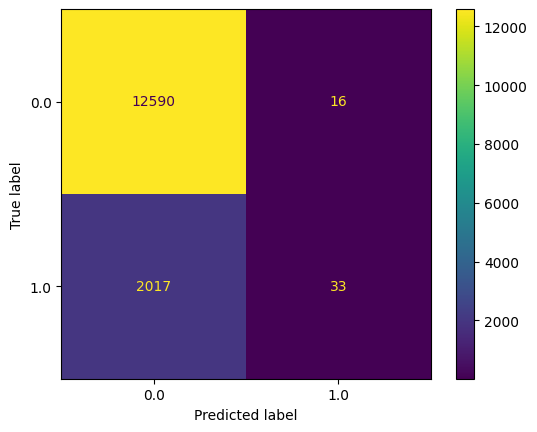

In [205]:
# To plot the confusion matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
# Construct the confusion matrix cm
cm = confusion_matrix(Y_cls_test, Y_pred, labels=log.classes_)
# Create a display to plot the confusion matrix
disp = ConfusionMatrixDisplay(cm,display_labels=log.classes_)
disp.plot()


In [206]:
# Accuracy Score
from sklearn.metrics import accuracy_score
print('the model accuracy: ',accuracy_score(Y_cls_test, Y_pred))

the model accuracy:  0.8612854803493449


In [207]:
# Classification report
from sklearn.metrics import classification_report
print(classification_report(Y_cls_test, Y_pred))

              precision    recall  f1-score   support

         0.0       0.86      1.00      0.93     12606
         1.0       0.67      0.02      0.03      2050

    accuracy                           0.86     14656
   macro avg       0.77      0.51      0.48     14656
weighted avg       0.84      0.86      0.80     14656



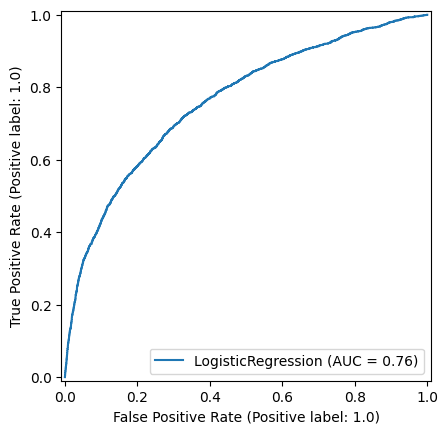

In [208]:
# Import the function from the package
from sklearn.metrics import RocCurveDisplay
# Apply the function by specifying the name of your model and test data.
Logreg_roc = RocCurveDisplay.from_estimator(log, X_cls_test, Y_cls_test)
